In [45]:
library(tidyverse)
library(dplyr)
library(tidyr)
library(cowplot)

In [75]:
cell_types <- c("Cardiomyocyte", "Endothelial", "Fibroblast", 
                "LEC", "Myeloid", "Neuronal", "Pericyte")

contrast_values <- c("up", "down")

q_val_threshold <- 0.05
top_n <- 5

ora_results_dir <- "overrepresentation_analysis_plots/"

# value to add so that the q value is not 0
eps <- 1e-10

In [76]:
extract_top_n_gene_sets <- function(ora_results_dir, cell_type, up_or_down,
                                    q_value_threshold, top_n, eps = 1e-10) {

  # make sure the contrast is either up or down
  if ( (up_or_down != "up") & (up_or_down != "down")) {
    message("up_or_down be either up or down")
    return(NULL)
  }
    
  # read the GSEA results CSV file
  results_file_path <- paste0(ora_results_dir, cell_type, "_fetal_disease_", up_or_down, "_ORA.csv")

  if (!file.exists(results_file_path)) {
    message("File not found: ", results_file_path)
    return(NULL)
  }
    
  gsea_results_df <- read_csv(results_file_path, 
                              show_col_types = FALSE, col_names = TRUE) 
  
  # filter significant results based on the q-value threshold
  significant_res_df <- gsea_results_df %>%
    filter(`Adjusted P-value` < q_value_threshold)
  
  # get top N upregulated gene sets
  sig_df <- significant_res_df %>%
    filter(`Odds Ratio` > 0) %>%
    arrange(`Adjusted P-value`) %>%
    head(top_n)
    
  sig_df$direction <- up_or_down
  sig_df$cell_type <- cell_type
  
  return(sig_df)
}

In [77]:
extract_top_n_gene_sets(ora_results_dir = ora_results_dir, cell_type = "Cardiomyocyte", 
                        up_or_down = "up",
                        q_value_threshold = 0.05, 
                       top_n = 5)

Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,disease,regulation,direction,cell_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
MSigDB_Hallmark_2020,E2F Targets,11/200,0.0004376747,0.01575629,0,0,3.623527,28.02448,PLK4;RAD51AP1;HELLS;CENPE;WEE1;MELK;DIAPH3;GINS4;HMGB2;MCM6;BRCA2,DCM,up,up,Cardiomyocyte
MSigDB_Hallmark_2020,E2F Targets,11/200,0.0004376747,0.01575629,0,0,3.623527,28.02448,PLK4;RAD51AP1;HELLS;CENPE;WEE1;MELK;DIAPH3;GINS4;HMGB2;MCM6;BRCA2,HCM,up,up,Cardiomyocyte
MSigDB_Hallmark_2020,E2F Targets,11/200,0.0004376747,0.01575629,0,0,3.623527,28.02448,PLK4;RAD51AP1;HELLS;CENPE;WEE1;MELK;DIAPH3;GINS4;HMGB2;MCM6;BRCA2,ICM,up,up,Cardiomyocyte
MSigDB_Hallmark_2020,Apical Junction,10/200,0.0016227215,0.02920899,0,0,3.266175,20.98077,COL16A1;MDK;ITGA10;AKT3;COL9A1;FSCN1;CNTN1;SIRPA;PARD6G;DSC3,DCM,up,up,Cardiomyocyte
MSigDB_Hallmark_2020,Apical Junction,10/200,0.0016227215,0.02920899,0,0,3.266175,20.98077,COL16A1;MDK;ITGA10;AKT3;COL9A1;FSCN1;CNTN1;SIRPA;PARD6G;DSC3,HCM,up,up,Cardiomyocyte


In [78]:
# initialize an empty list to store the data frames
all_dfs_list <- list()

# loop through each cell_type and contrast
for (cell_type in cell_types) {
  for (contrast in contrast_values)  {
    
    # call the function to extract the top N gene sets
    combined_df <- extract_top_n_gene_sets(ora_results_dir = ora_results_dir, 
                                           cell_type = cell_type, 
                                           up_or_down = contrast,
                                           q_value_threshold = 0.05, 
                                           top_n = 5)

    # if not null, then append the result to the list
    if (! is.null(combined_df) ) {
        all_dfs_list <- append(all_dfs_list, list(combined_df))
    }
      
  }
}

# combine all data frames in the list into one
all_ora_df <- bind_rows(all_dfs_list)

In [79]:
# replace underscore with space
all_ora_df$Term <- gsub("_", " ", all_ora_df$Term)

# perform text wrapping for GO terms at natural spaces to fit within a width of 20 characters
library(stringr)
all_ora_df$Term <- str_wrap(all_ora_df$Term, width = 25)

In [80]:
output_dir <- "ORA_facet_plots/"
dir.create(output_dir)

Warning message in dir.create(output_dir):
“'ORA_facet_plots' already exists”


In [81]:
all_ora_df['neg_log10_q'] <- -1 * log10(all_ora_df["Adjusted P-value"])

In [82]:
produce_cell_type_plot <- function(all_results_df, cell_type_val) {
  
    # filter to the desired cell type
    cell_type_df <- all_results_df %>%
    filter(cell_type == cell_type_val)

    p <- ggplot(cell_type_df, aes(x = `Odds Ratio`, y = Term, size = neg_log10_q, color = `Odds Ratio`)) +
        geom_point() +
        scale_color_gradient2(
            low = "red",  
            mid = "white", 
            high = "blue", 
            midpoint = 0 
        ) +
        facet_wrap(~ direction, ncol = 2, scales = "free_y") +  
        scale_size_continuous(range = c(1, 10)) +  
        theme_minimal() +
        theme(axis.text.y = element_text(size = 8),  
              strip.text = element_text(size = 10),  
              legend.title = element_text(size = 10),
              legend.text = element_text(size = 8), hjust = 0.5,
              plot.title = element_text(size = 14, hjust = 0.5), 
              legend.position = "bottom") +
        labs(x = "Odds Ratio", y = "Term", size = "-log10(q)", title = paste("Cell Type:", cell_type))
      
    return(p)
}

### Produce a plot that includes all of the cell types

For simplicity of the figure, filter to those terms that have more than 5 instances overall as significant

In [83]:
stricter_q_val <- 0.05
further_filtered_df <- all_ora_df %>% dplyr::filter(`Adjusted P-value` < stricter_q_val)	

In [84]:
counts_per_term <- sort(table(further_filtered_df$Term))

In [85]:
most_common_terms <- names(counts_per_term[counts_per_term > 0])
length(most_common_terms)

[1] 12

In [86]:
most_common_terms

[1] "Coagulation"                        "Epithelial Mesenchymal\nTransition"
 [3] "Xenobiotic Metabolism"              "E2F Targets"                       
 [5] "IL-2/STAT5 Signaling"               "Inflammatory Response"             
 [7] "Interferon Gamma Response"          "PI3K/AKT/mTOR Signaling"           
 [9] "Apical Junction"                    "Apoptosis"                         
[11] "Myogenesis"                         "TNF-alpha Signaling via\nNF-kB"

In [87]:
further_filtered_df <- further_filtered_df %>% filter(Term %in% most_common_terms)

In [88]:
further_filtered_df$disease

[1] "DCM" "HCM" "ICM" "DCM" "HCM" "DCM" "HCM" "ICM" "DCM" "DCM" "DCM" "HCM"
[13] "ICM" "DCM" "HCM" "DCM" "HCM" "ICM" "DCM" "HCM" "DCM" "HCM" "ICM" "DCM"
[25] "HCM" "DCM" "HCM" "ICM" "DCM" "HCM" "ICM" "DCM" "DCM" "DCM" "HCM" "ICM"
[37] "DCM" "HCM" "DCM" "HCM" "ICM" "DCM" "HCM" "DCM" "HCM" "ICM" "DCM" "HCM"

In [89]:
# order these thematically:
further_filtered_df$Term <- factor(further_filtered_df$Term, c("Xenobiotic Metabolism",
                                                               "Apical Junction",
                                                               "Epithelial Mesenchymal\nTransition",
                                                               "E2F Targets",
                                                               "PI3K/AKT/mTOR Signaling",
                                                               "Myogenesis",
                                                               "Adipogenesis",
                                                               "Hypoxia",
                                                               "Apoptosis",
                                                               "Coagulation",
                                                               "Inflammatory Response",
                                                               "Interferon Gamma Response",
                                                               "Interferon Alpha Response",
                                                               "IL-2/STAT5 Signaling",
                                                               "TNF-alpha Signaling via\nNF-kB"
                                                              )
                                  )

In [90]:
further_filtered_df$Term

[1] E2F Targets                        E2F Targets                       
 [3] E2F Targets                        Apical Junction                   
 [5] Apical Junction                    TNF-alpha Signaling via\nNF-kB    
 [7] TNF-alpha Signaling via\nNF-kB     TNF-alpha Signaling via\nNF-kB    
 [9] Interferon Gamma Response          Inflammatory Response             
[11] Myogenesis                         Myogenesis                        
[13] Myogenesis                         Interferon Gamma Response         
[15] Interferon Gamma Response          Apical Junction                   
[17] Apical Junction                    Apical Junction                   
[19] Epithelial Mesenchymal\nTransition Epithelial Mesenchymal\nTransition
[21] TNF-alpha Signaling via\nNF-kB     TNF-alpha Signaling via\nNF-kB    
[23] TNF-alpha Signaling via\nNF-kB     Xenobiotic Metabolism             
[25] Xenobiotic Metabolism              PI3K/AKT/mTOR Signaling           
[27] PI3K/AKT/mTOR Signaling            PI3K/AKT/mTOR Signaling           
[29] Myogenesis                         Myogenesis                        
[31] Myogenesis                         Coagulation                       
[33] Apoptosis                          IL-2/STAT5 Signaling              
[35] IL-2/STAT5 Signaling               IL-2/STAT5 Signaling              
[37] Inflammatory Response              Inflammatory Response             
[39] TNF-alpha Signaling via\nNF-kB     TNF-alpha Signaling via\nNF-kB    
[41] TNF-alpha Signaling via\nNF-kB     Apoptosis                         
[43] Apoptosis                          TNF-alpha Signaling via\nNF-kB    
[45] TNF-alpha Signaling via\nNF-kB     TNF-alpha Signaling via\nNF-kB    
[47] Apoptosis                          Apoptosis                         
15 Levels: Xenobiotic Metabolism ... TNF-alpha Signaling via\nNF-kB

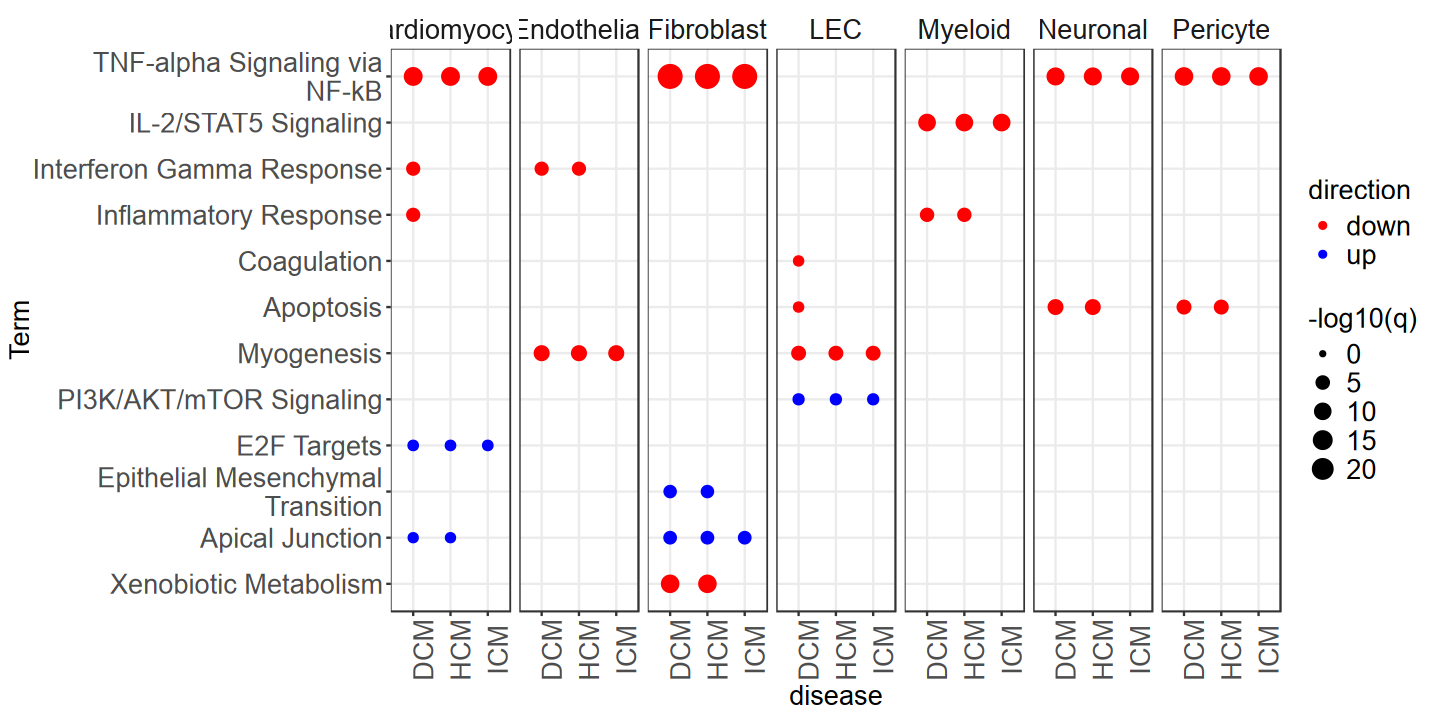

In [97]:
options(repr.plot.width = 12, repr.plot.height = 6)

p3 <- ggplot(data = further_filtered_df, mapping = aes(x = disease, y = Term, size = neg_log10_q, color = direction)) + 
        scale_color_manual(values = c("down" = "red", "up" = "blue")) + 
        geom_point() + 
        facet_wrap(~ cell_type, nrow = 1) + 
        theme_bw() +
          scale_size_continuous(
            name = "-log10(q)",  
            breaks = c(0, 5, 10, 15, 20),  
            limits = c(0, max(further_filtered_df$neg_log10_q, na.rm = TRUE)) 
        ) +
        theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16, angle = 90),
         axis.text.y = element_text(size = 16), 
         strip.text.x = element_text(size = 16),
              strip.background = element_blank() )

ggsave(paste0(ora_results_dir, "overall_fetal_disease_ora_facet_plot.pdf"), 
         plot = p3, width = 12, height = 6)

p3